# 02. 데이터 오버뷰

## 분석 개요

공개 [코스메틱 이커머스 이벤트 데이터](https://www.kaggle.com/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop)의 원본 이벤트를 살펴본다. 한 행은 한 번의 조회·담기·담기 취소·구매 기록이며, 관측 기간은 2019-10-01부터 2020-02-29까지다.

이 노트북은 이벤트 규모와 구성, 일별 기록 흐름, 주요 결측을 확인한다. 이벤트 유형별 비중의 분모는 원본 이벤트 20,692,840건이다. 동일 사용자나 상품의 구매 전환율은 [04 EDA](04_eda.ipynb)에서 별도로 분석한다. [`sql/data_overview.sql`](../sql/data_overview.sql)의 검증된 캐시를 사용한다.

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / 'cache_context.json').is_file() and (p / 'sql').is_dir())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from query_cache import QueryCache

load_dotenv(PROJECT_ROOT / '.env')
required_env = ('DB_USER', 'DB_PASSWORD', 'DB_HOST', 'DB_PORT', 'DB_NAME')
if any(not os.getenv(k) for k in required_env):
    raise RuntimeError('캐시 출처 확인용 .env 항목이 부족하다.')
# Engine은 DB 출처 식별에만 사용한다. 캐시 조회는 DB에 연결하지 않는다.
engine = create_engine(URL.create(
    'mysql+pymysql', username=os.environ['DB_USER'], password=os.environ['DB_PASSWORD'],
    host=os.environ['DB_HOST'], port=int(os.environ['DB_PORT']), database=os.environ['DB_NAME'],
))
COMPATIBILITY_FILE = PROJECT_ROOT / 'sql' / 'cache_compatibility.json'

FINAL_CACHE = QueryCache(
    engine=engine, sql_file=PROJECT_ROOT / 'sql' / 'data_overview.sql',
    upstream_sql_files=(), cache_dir=PROJECT_ROOT / 'cache',
    context_file=PROJECT_ROOT / 'cache_context.json',
)
def read_overview(name, **kwargs):
    return FINAL_CACHE.read_compatible_cached(
        name, compatibility_file=COMPATIBILITY_FILE, **kwargs
    )


## 1. 데이터 개요

원본 `events`는 조회, 담기, 장바구니 제거, 구매 행동 한 건이 한 행인 로그다. 관측 기간과 행 수를 먼저 확인하고, 이후 식별자·이벤트 유형·결측 규모를 살펴본다.

In [2]:
base = read_overview('base_scalars').iloc[0]
display(pd.DataFrame({
    '항목': ['원본 이벤트 행', '컬럼 수', '첫 이벤트', '마지막 이벤트'],
    '확인값': [f"{int(base['행수']):,}", 9, str(base['시작']), str(base['종료'])],
}))
assert int(base['행수']) == 20_692_840


[base_scalars] cache HIT 6d43091c3e2d · 1행


,항목,확인값
0,원본 이벤트 행,"20,692,840"
1,컬럼 수,9
2,첫 이벤트,2019-10-01 00:00:00
3,마지막 이벤트,2020-02-29 23:59:59


## 2. 주요 컬럼과 저장 타입

아래 타입은 pandas 추정 dtype이 아니라 `events` 테이블의 MySQL 저장 타입이다. 컬럼의 역할을 먼저 보면 뒤의 세션·상품·사용자 연결 방식이 분명해진다. 스키마 확인 SQL은 [`sql/data_overview.sql`](../sql/data_overview.sql)에 있다.

| 컬럼 | MySQL 저장 타입 | 분석에서의 역할 |
|---|---|---|
| `event_time` | `DATETIME` | 행동 순서·관측 기간 |
| `event_type` | `VARCHAR(20)` | view/cart/remove_from_cart/purchase |
| `product_id` | `BIGINT` | 동일 상품 연결 |
| `category_id` | `BIGINT` | 상품군 식별 |
| `category_code` | `VARCHAR(120)` | 상품군 보조 정보 |
| `brand` | `VARCHAR(60)` | 브랜드 보조 정보 |
| `price` | `DECIMAL(10,2)` | 가격 품질·구매 금액 |
| `user_id` | `BIGINT` | 사용자 연결·실험 배정 |
| `user_session` | `CHAR(36)`, NULL 가능 | 방문 경계 |

## 3. 데이터 규모

전체 관측 기간의 식별자 수다. 비결측 세션 수는 **유효 세션 마트의 행 수와 다르다**.

In [3]:
users = int(read_overview('distinct_users').iloc[0]['고유_사용자'])
products = int(read_overview('overview_raw_product_count').iloc[0]['raw_product_count'])
sessions = int(read_overview('distinct_sessions').iloc[0]['고유_세션'])
assert (users, products, sessions) == (1_639_358, 54_571, 4_535_941)
display(pd.DataFrame({'식별자':['사용자','상품','비결측 세션'], '고유 수':[users,products,sessions]}))


[distinct_users] cache HIT 2891d02b1215 · 1행
[overview_raw_product_count] cache HIT 52e9b6c806f4 · 1행
[distinct_sessions] cache HIT e7e32d4248b3 · 1행


,식별자,고유 수
0,사용자,1639358
1,상품,54571
2,비결측 세션,4535941


## 4. 이벤트 유형

[`sql/data_overview.sql`](../sql/data_overview.sql)의 일자×유형 집계에 대응하는 검증 캐시를 유형별로 합한다. 분모는 원본 이벤트 전체이며 원본을 다시 스캔하지 않는다.

In [4]:
daily = read_overview('daily_trend')
types = daily.groupby('event_type', as_index=False)['event_count'].sum()
assert set(types['event_type']) == {'view','cart','remove_from_cart','purchase'}
assert int(types['event_count'].sum()) == int(base['행수'])
types['전체 이벤트 대비 (%)'] = (types['event_count'] / int(base['행수']) * 100).round(3)
display(types.sort_values('event_count',ascending=False).reset_index(drop=True))


[daily_trend] cache HIT 720112d119df · 608행


,event_type,event_count,전체 이벤트 대비 (%)
0,view,9657821,46.672
1,cart,5768333,27.876
2,remove_from_cart,3979679,19.232
3,purchase,1287007,6.220


In [5]:
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'plotly_mimetype'
COLORS = {'view': '#3B82F6', 'cart': '#F59E0B', 'purchase': '#10B981', 'neutral': '#94A3B8'}


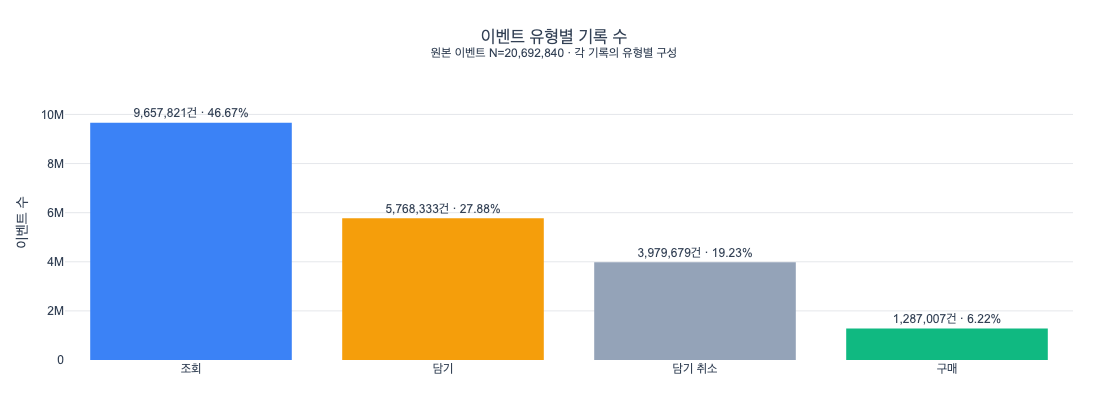

In [6]:
event_order = ['view', 'cart', 'remove_from_cart', 'purchase']
event_labels = {'view': '조회', 'cart': '담기', 'remove_from_cart': '담기 취소', 'purchase': '구매'}
event_colors = [COLORS['view'], COLORS['cart'], COLORS['neutral'], COLORS['purchase']]
event_plot = types.set_index('event_type').loc[event_order].reset_index()

fig = go.Figure(go.Bar(
    x=[event_labels[x] for x in event_plot['event_type']],
    y=event_plot['event_count'],
    marker_color=event_colors,
    text=[f'{n:,}건 · {rate:.2f}%' for n, rate in zip(event_plot['event_count'], event_plot['전체 이벤트 대비 (%)'])],
    textposition='outside',
    hovertemplate='%{x}<br>이벤트 %{y:,}건<extra></extra>',
))
fig.update_layout(
    title={'text': '이벤트 유형별 기록 수<br><sup>원본 이벤트 N=20,692,840 · 각 기록의 유형별 구성</sup>', 'x': 0.5},
    template='none', paper_bgcolor='white', plot_bgcolor='white', showlegend=False,
    font={'family': 'Arial, Apple SD Gothic Neo, sans-serif', 'color': '#334155'},
    margin={'l': 65, 'r': 35, 't': 85, 'b': 50}, height=410,
    yaxis={'title': '이벤트 수', 'gridcolor': '#E5E7EB', 'zeroline': False, 'range': [0, 11_200_000]},
    xaxis={'title': None, 'showgrid': False},
)
fig.show()


유형별 비중은 이벤트 기록의 구성비다. 조회·담기·구매의 순서나 동일 사용자·상품 여부는 이 표와 차트에서 연결하지 않는다.

## 5. 일별 이벤트 흐름

전체 이벤트를 일자별로 합산해 관측 기간의 기록 규모를 확인한다. 분모는 각 날짜에 기록된 이벤트이며, 사용자 수나 구매 전환율을 나타내지 않는다.

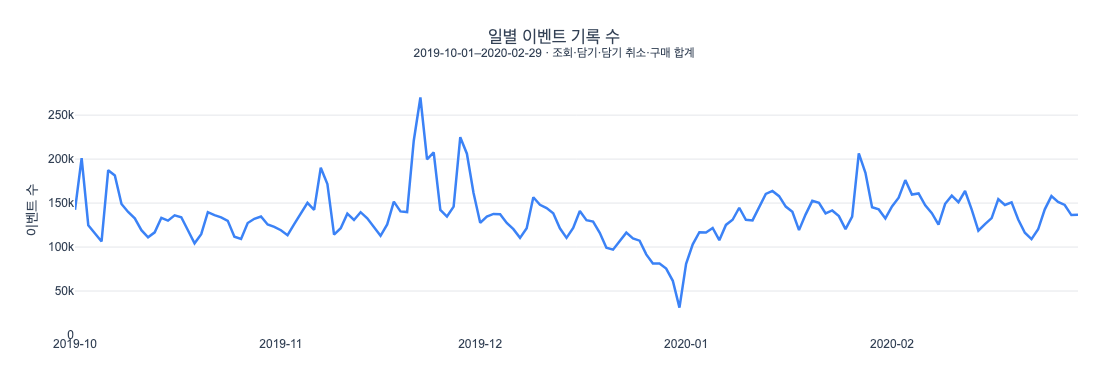

In [7]:
daily_total = daily.groupby('event_date', as_index=False)['event_count'].sum()
daily_total['event_date'] = pd.to_datetime(daily_total['event_date'])
daily_total = daily_total.sort_values('event_date')
assert len(daily_total) == 152
assert int(daily_total['event_count'].sum()) == int(base['행수'])
assert daily_total['event_date'].min() == pd.Timestamp('2019-10-01')
assert daily_total['event_date'].max() == pd.Timestamp('2020-02-29')

fig = go.Figure(go.Scatter(
    x=daily_total['event_date'], y=daily_total['event_count'],
    mode='lines', line={'color': COLORS['view'], 'width': 2.5},
    hovertemplate='%{x|%Y-%m-%d}<br>이벤트 %{y:,}건<extra></extra>',
))
fig.update_layout(
    title={'text': '일별 이벤트 기록 수<br><sup>2019-10-01–2020-02-29 · 조회·담기·담기 취소·구매 합계</sup>', 'x': 0.5},
    template='none', paper_bgcolor='white', plot_bgcolor='white', showlegend=False,
    font={'family': 'Arial, Apple SD Gothic Neo, sans-serif', 'color': '#334155'},
    margin={'l': 75, 'r': 30, 't': 85, 'b': 55}, height=390,
    xaxis={'title': None, 'showgrid': False, 'tickformat': '%Y-%m', 'dtick': 'M1'},
    yaxis={'title': '이벤트 수', 'gridcolor': '#E5E7EB', 'zeroline': False, 'rangemode': 'tozero'},
)
fig.show()


## 6. 최소 품질 확인

분모는 원본 이벤트 전체다. 세션 식별자가 없거나 가격이 음수인 이벤트는 이후 유효 세션·이벤트 집계에서 구분해 처리한다. 카테고리·브랜드 결측만을 이유로 구매 경로의 행을 추가 제거하지 않는다.

In [8]:
quality = pd.DataFrame({
    '항목':['user_session 결측','category_code 결측','brand 결측','음수 가격','0원 가격'],
    '이벤트 수':[int(base[k]) for k in ('null_user_session','null_category_code','null_brand','price_음수','price_0원')],
})
quality['원본 이벤트 대비 (%)'] = (quality['이벤트 수'] / int(base['행수']) * 100).round(3)
assert quality.loc[quality['항목'].eq('user_session 결측'),'이벤트 수'].iloc[0] == 4_598
assert quality.loc[quality['항목'].eq('음수 가격'),'이벤트 수'].iloc[0] == 131
display(quality)


,항목,이벤트 수,원본 이벤트 대비 (%)
0,user_session 결측,4598,0.022
1,category_code 결측,20339246,98.291
2,brand 결측,8757117,42.320
3,음수 가격,131,0.001
4,0원 가격,104157,0.503


카테고리 코드와 브랜드는 결측이 많아 해당 속성별 비교에 사용할 수 있는 기록이 제한된다. 세션 식별자 결측과 음수 가격은 [03 마트 개요](03_mart_overview.ipynb)의 집계 기준에서 구분한다.

## 7. 요약

원본에는 20,692,840건의 이벤트와 네 가지 행동 유형이 기록됐다. 이벤트 구성비는 행동 기록의 분포이며 구매 전환율을 뜻하지 않는다. 세션 식별자·가격 기준을 적용한 분석 마트와 사용자×상품 단위는 [03 마트 개요](03_mart_overview.ipynb)에서 확인한다.